In [28]:
import pandas as pd
from db_connection import conn, cursor

In [29]:
query = """
SELECT
    w.location_id,
    l.location,
    w.[date],
    w.rainfall,
    w.temperature,
    w.humidity,
    w.pressure,
    w.wind_speed,
    r.river_discharge,
    CASE 
        WHEN lb.date IS NOT NULL THEN 1
        ELSE 0
    END AS flood

FROM weather_data w
JOIN river_data r ON w.location_id = r.location_id
AND CAST(w.[date] AS DATE) = CAST(r.[date] AS DATE)

JOIN location_data l ON w.location_id = l.location_id

LEFT JOIN label_data lb 
ON w.date = lb.date
AND w.location_id = lb.location_id
"""

In [30]:
df = pd.read_sql(query,conn)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_28960\785092515.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,conn)


In [31]:
df.head()

,location_id,location,date,rainfall,temperature,humidity,pressure,wind_speed,river_discharge,flood
0,1,Hue,2001-07-01,0.0,28.600000,68.0,1000.400024,24.799999,0.53,0
1,1,Hue,2001-07-02,0.2,29.100000,70.0,998.700012,20.900000,0.44,0
2,1,Hue,2001-07-03,1.8,28.600000,79.0,999.599976,6.900000,0.42,0
3,1,Hue,2001-07-04,13.8,27.799999,85.0,999.900024,11.500000,0.44,0
4,1,Hue,2001-07-05,0.0,28.799999,74.0,997.500000,25.200001,0.41,0


In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18286 entries, 0 to 18285
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   location_id      18286 non-null  int64  
 1   location         18286 non-null  str    
 2   date             18286 non-null  object 
 3   rainfall         18286 non-null  float64
 4   temperature      18286 non-null  float64
 5   humidity         18286 non-null  float64
 6   pressure         18286 non-null  float64
 7   wind_speed       18286 non-null  float64
 8   river_discharge  18286 non-null  float64
 9   flood            18286 non-null  int64  
dtypes: float64(6), int64(2), object(1), str(1)
memory usage: 1.4+ MB


In [33]:
df["date"] =pd.to_datetime(df["date"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18286 entries, 0 to 18285
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype        
---  ------           --------------  -----        
 0   location_id      18286 non-null  int64        
 1   location         18286 non-null  str          
 2   date             18286 non-null  datetime64[s]
 3   rainfall         18286 non-null  float64      
 4   temperature      18286 non-null  float64      
 5   humidity         18286 non-null  float64      
 6   pressure         18286 non-null  float64      
 7   wind_speed       18286 non-null  float64      
 8   river_discharge  18286 non-null  float64      
 9   flood            18286 non-null  int64        
dtypes: datetime64[s](1), float64(6), int64(2), str(1)
memory usage: 1.4 MB


In [34]:
df.describe()

,location_id,date,rainfall,temperature,humidity,pressure,wind_speed,river_discharge,flood
count,18286.000000,18286,18286.000000,18286.000000,18286.000000,18286.000000,18286.000000,18286.000000,18286.000000
mean,1.500000,2014-01-05 00:00:00,7.876736,25.758537,83.012851,1009.344411,14.339380,23.587589,0.035984
min,1.000000,2001-07-01 00:00:00,0.000000,14.100000,45.000000,984.400024,4.200000,0.080000,0.000000
25%,1.000000,2007-10-03 06:00:00,0.200000,23.299999,80.000000,1005.299988,11.300000,0.670000,0.000000
50%,1.500000,2014-01-05 00:00:00,2.200000,26.000000,84.000000,1009.000000,13.600000,6.530000,0.000000
75%,2.000000,2020-04-08 18:00:00,8.400000,28.400000,88.000000,1013.299988,16.600000,14.850000,0.000000
max,2.000000,2026-07-12 00:00:00,398.799988,34.599998,97.000000,1028.400024,64.599998,1569.359985,1.000000
std,0.500014,NaN,16.872527,3.285306,7.064243,5.201703,4.613390,68.787972,0.186255


# EDA 

In [35]:
df = df.sort_values(["location", "date"])

df["target_d1"] = (
    df.groupby("location")["flood"].shift(-1)
)

df["target_d2"] = (
    df.groupby("location")["flood"].shift(-2)
)

df["target_d3"] = (
    df.groupby("location")["flood"].shift(-3)
)

df.head()

,location_id,location,date,rainfall,temperature,humidity,pressure,wind_speed,river_discharge,flood,target_d1,target_d2,target_d3
0,1,Hue,2001-07-01,0.0,28.600000,68.0,1000.400024,24.799999,0.53,0,0.0,0.0,0.0
1,1,Hue,2001-07-02,0.2,29.100000,70.0,998.700012,20.900000,0.44,0,0.0,0.0,0.0
2,1,Hue,2001-07-03,1.8,28.600000,79.0,999.599976,6.900000,0.42,0,0.0,0.0,0.0
3,1,Hue,2001-07-04,13.8,27.799999,85.0,999.900024,11.500000,0.44,0,0.0,0.0,0.0
4,1,Hue,2001-07-05,0.0,28.799999,74.0,997.500000,25.200001,0.41,0,0.0,0.0,0.0


In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

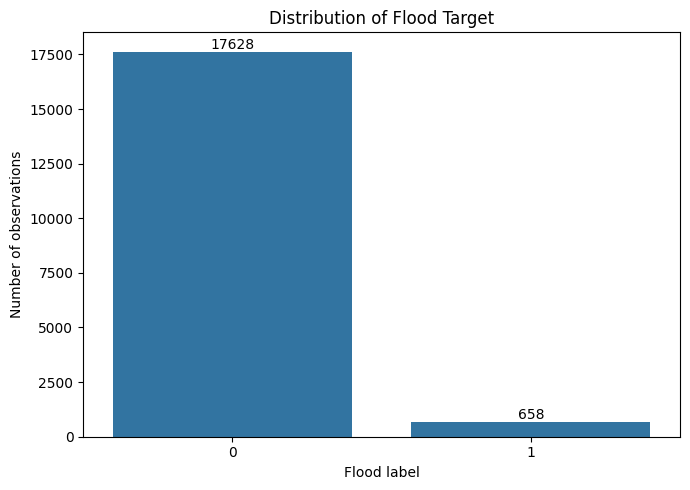

In [37]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="flood"
)

plt.title("Distribution of Flood Target")
plt.xlabel("Flood label")
plt.ylabel("Number of observations")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

- Số ngày không lũ cao hơn rất nhiều so với ngày lũ
- Không dùng Accuracy làm metric chính
- Một model dự đoán tất cả là 0 vẫn đạt:
- Accuracy=96,4%

- Dùng Recall= TP/(TP + FN)  trong tất cả ngày có lũ, model phát hiện được bao nhiêu phần trăm
- Dùng Precision = TP/(TP + FP) trong tất cả lần model cảnh báo có lũ, bao nhiêu lần đúng
- Dùng F1-score F1= 2* (Pre*Re)/(Pre + Re) cân bằng giữa Recall và Precision
- Dùng F2-score F2= 5*(Pre*Re)/(4*Pre + Re) 
- Dùng PR-AUC đánh giá Precision-Recall trên nhiều ngưỡng probability

In [50]:
location_flood_summary = (
    df.groupby("location")
      .agg(
          total_samples=("flood", "count"),
          flood_days=("flood", "sum"),
          flood_rate=("flood", "mean"),
          rainfall_mean=("rainfall", "mean"),
          discharge_mean=("river_discharge", "mean")
      )
      .reset_index()
)

location_flood_summary["flood_rate_percent"] = (
    location_flood_summary["flood_rate"] * 100
)

location_flood_summary

,location,total_samples,flood_days,flood_rate,rainfall_mean,discharge_mean,flood_rate_percent
0,Hue,9143,28,0.003062,7.913158,1.728051,0.306245
1,Quang Nam,9143,630,0.068905,7.840315,45.447127,6.890517


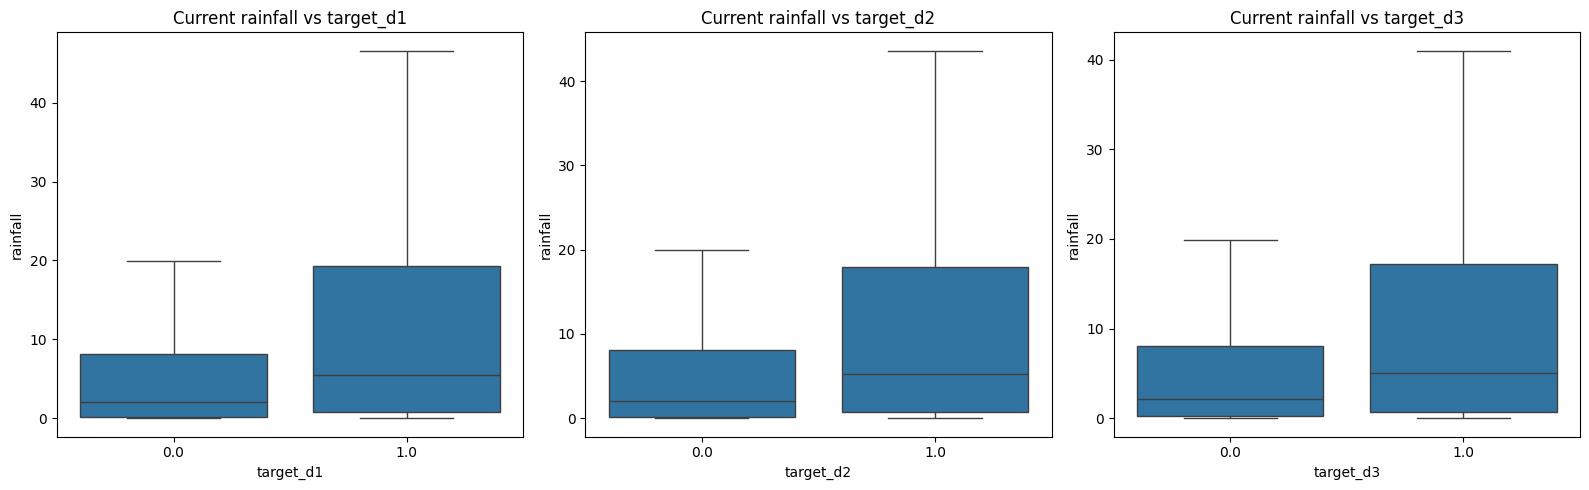

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, target in zip(
    axes,
    ["target_d1", "target_d2", "target_d3"]
):
    sns.boxplot(
        data=df,
        x=target,
        y="rainfall",
        showfliers=False,
        ax=ax
    )

    ax.set_title(f"Current rainfall vs {target}")

plt.tight_layout()
plt.show()

- những ngày sau đó xảy ra lũ thì thường có lượng mưa hiện tại cao hơn những ngày sau đó không xảy ra lũ --> rainfall là 1 feature có ích
- mưa lớn thường xuất hiện phổ biến trong nhóm có lũ
- Việc nhóm có lũ vẫn có một số ngày rainfall bằng 0 cho thấy lũ có thể do lượng nước đã tích lũy từ trước -> tạo 3daysrainfall và 7daysrainfall

In [39]:
df["rainfall_3d"] = (
    df.groupby("location")["rainfall"]
    .transform(
        lambda x: x.rolling(
            window=3,
            min_periods=1
        ).sum()
    )
)
df.head()

,location_id,location,date,rainfall,temperature,humidity,pressure,wind_speed,river_discharge,flood,target_d1,target_d2,target_d3,rainfall_3d
0,1,Hue,2001-07-01,0.0,28.600000,68.0,1000.400024,24.799999,0.53,0,0.0,0.0,0.0,0.0
1,1,Hue,2001-07-02,0.2,29.100000,70.0,998.700012,20.900000,0.44,0,0.0,0.0,0.0,0.2
2,1,Hue,2001-07-03,1.8,28.600000,79.0,999.599976,6.900000,0.42,0,0.0,0.0,0.0,2.0
3,1,Hue,2001-07-04,13.8,27.799999,85.0,999.900024,11.500000,0.44,0,0.0,0.0,0.0,15.8
4,1,Hue,2001-07-05,0.0,28.799999,74.0,997.500000,25.200001,0.41,0,0.0,0.0,0.0,15.6


In [40]:
df["rainfall_7d"] = (
    df.groupby("location")["rainfall"]
    .transform(
        lambda x: x.rolling(
            window=7,
            min_periods=1
        ).sum()
    )
)
df.head()

,location_id,location,date,rainfall,temperature,humidity,pressure,wind_speed,river_discharge,flood,target_d1,target_d2,target_d3,rainfall_3d,rainfall_7d
0,1,Hue,2001-07-01,0.0,28.600000,68.0,1000.400024,24.799999,0.53,0,0.0,0.0,0.0,0.0,0.0
1,1,Hue,2001-07-02,0.2,29.100000,70.0,998.700012,20.900000,0.44,0,0.0,0.0,0.0,0.2,0.2
2,1,Hue,2001-07-03,1.8,28.600000,79.0,999.599976,6.900000,0.42,0,0.0,0.0,0.0,2.0,2.0
3,1,Hue,2001-07-04,13.8,27.799999,85.0,999.900024,11.500000,0.44,0,0.0,0.0,0.0,15.8,15.8
4,1,Hue,2001-07-05,0.0,28.799999,74.0,997.500000,25.200001,0.41,0,0.0,0.0,0.0,15.6,15.8


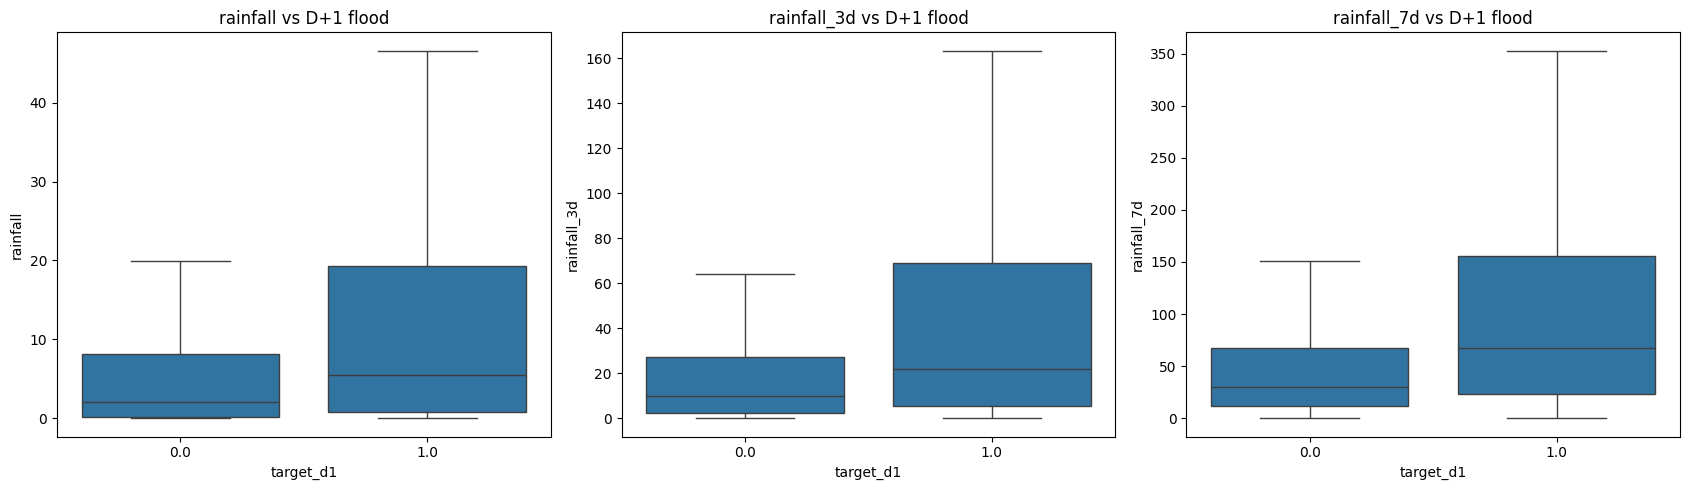

In [41]:
rain_features = [
    "rainfall",
    "rainfall_3d",
    "rainfall_7d"
]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, feature in zip(axes, rain_features):
    sns.boxplot(
        data=df,
        x="target_d1",
        y=feature,
        showfliers=False,
        ax=ax
    )

    ax.set_title(f"{feature} vs D+1 flood")

plt.tight_layout()
plt.show()

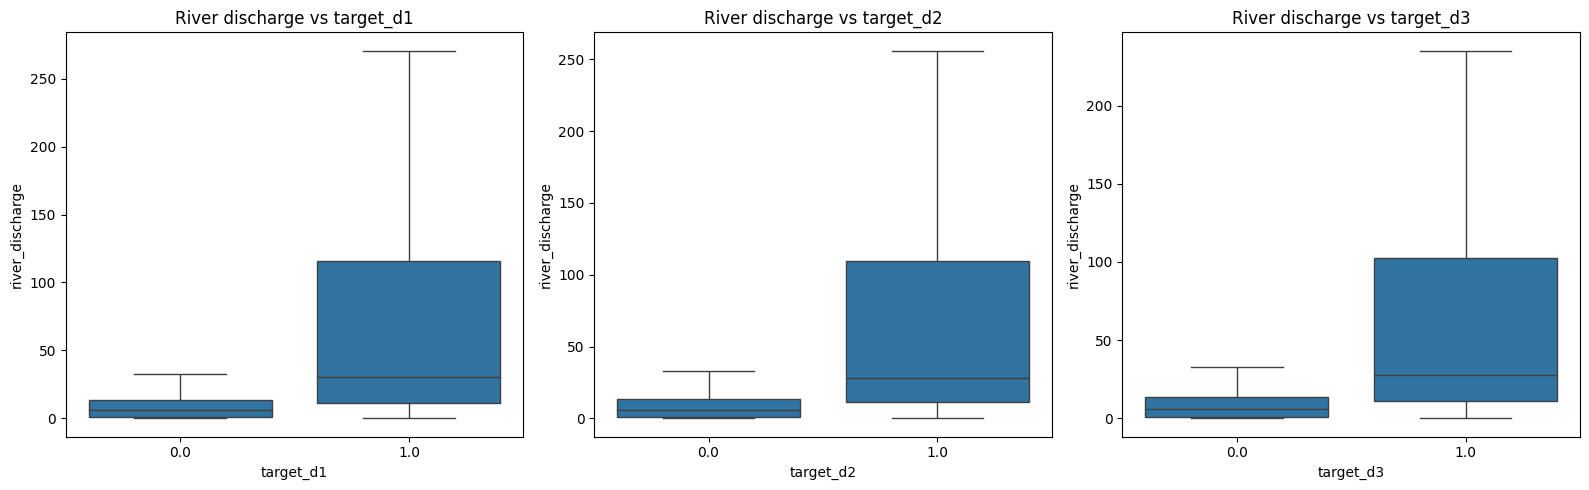

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, target in zip(
    axes,
    ["target_d1", "target_d2", "target_d3"]
):
    sns.boxplot(
        data=df,
        x=target,
        y="river_discharge",
        showfliers=False,
        ax=ax
    )

    ax.set_title(f"River discharge vs {target}")

plt.tight_layout()
plt.show()

In [43]:
df["discharge_change_1d"] = (
    df.groupby("location")["river_discharge"]
    .diff(1)
    .fillna(0)
)
df.head()

,location_id,location,date,rainfall,temperature,humidity,pressure,wind_speed,river_discharge,flood,target_d1,target_d2,target_d3,rainfall_3d,rainfall_7d,discharge_change_1d
0,1,Hue,2001-07-01,0.0,28.600000,68.0,1000.400024,24.799999,0.53,0,0.0,0.0,0.0,0.0,0.0,0.00
1,1,Hue,2001-07-02,0.2,29.100000,70.0,998.700012,20.900000,0.44,0,0.0,0.0,0.0,0.2,0.2,-0.09
2,1,Hue,2001-07-03,1.8,28.600000,79.0,999.599976,6.900000,0.42,0,0.0,0.0,0.0,2.0,2.0,-0.02
3,1,Hue,2001-07-04,13.8,27.799999,85.0,999.900024,11.500000,0.44,0,0.0,0.0,0.0,15.8,15.8,0.02
4,1,Hue,2001-07-05,0.0,28.799999,74.0,997.500000,25.200001,0.41,0,0.0,0.0,0.0,15.6,15.8,-0.03


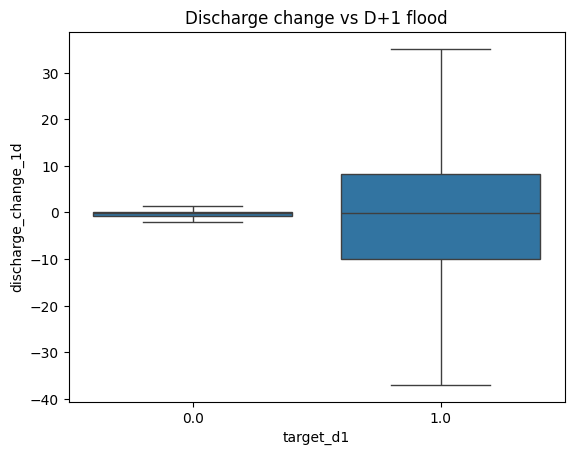

In [44]:
sns.boxplot(
    data=df,
    x="target_d1",
    y="discharge_change_1d",
    showfliers=False
)

plt.title("Discharge change vs D+1 flood")
plt.show()

In [45]:
df["month"] = df["date"].dt.month

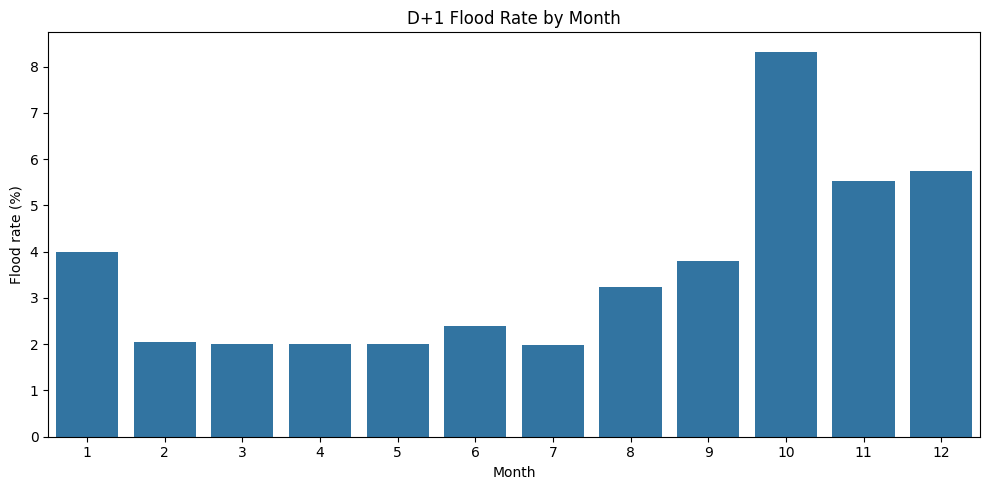

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

monthly_d1 = (
    df.groupby("month")["target_d1"]
      .agg(
          total_samples="count",
          flood_days="sum",
          flood_rate="mean"
      )
      .reset_index()
)

monthly_d1["flood_rate_percent"] = (
    monthly_d1["flood_rate"] * 100
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=monthly_d1,
    x="month",
    y="flood_rate_percent"
)

plt.title("D+1 Flood Rate by Month")
plt.xlabel("Month")
plt.ylabel("Flood rate (%)")
plt.tight_layout()
plt.show()

In [47]:
def assign_season(month):
    if month in [9, 10, 11, 12]:
        return "rainy_season"
    return "dry_season"

df["season"] = df["month"].apply(assign_season)

df.head()

,location_id,location,date,rainfall,temperature,humidity,pressure,wind_speed,river_discharge,flood,target_d1,target_d2,target_d3,rainfall_3d,rainfall_7d,discharge_change_1d,month,season
0,1,Hue,2001-07-01,0.0,28.600000,68.0,1000.400024,24.799999,0.53,0,0.0,0.0,0.0,0.0,0.0,0.00,7,dry_season
1,1,Hue,2001-07-02,0.2,29.100000,70.0,998.700012,20.900000,0.44,0,0.0,0.0,0.0,0.2,0.2,-0.09,7,dry_season
2,1,Hue,2001-07-03,1.8,28.600000,79.0,999.599976,6.900000,0.42,0,0.0,0.0,0.0,2.0,2.0,-0.02,7,dry_season
3,1,Hue,2001-07-04,13.8,27.799999,85.0,999.900024,11.500000,0.44,0,0.0,0.0,0.0,15.8,15.8,0.02,7,dry_season
4,1,Hue,2001-07-05,0.0,28.799999,74.0,997.500000,25.200001,0.41,0,0.0,0.0,0.0,15.6,15.8,-0.03,7,dry_season


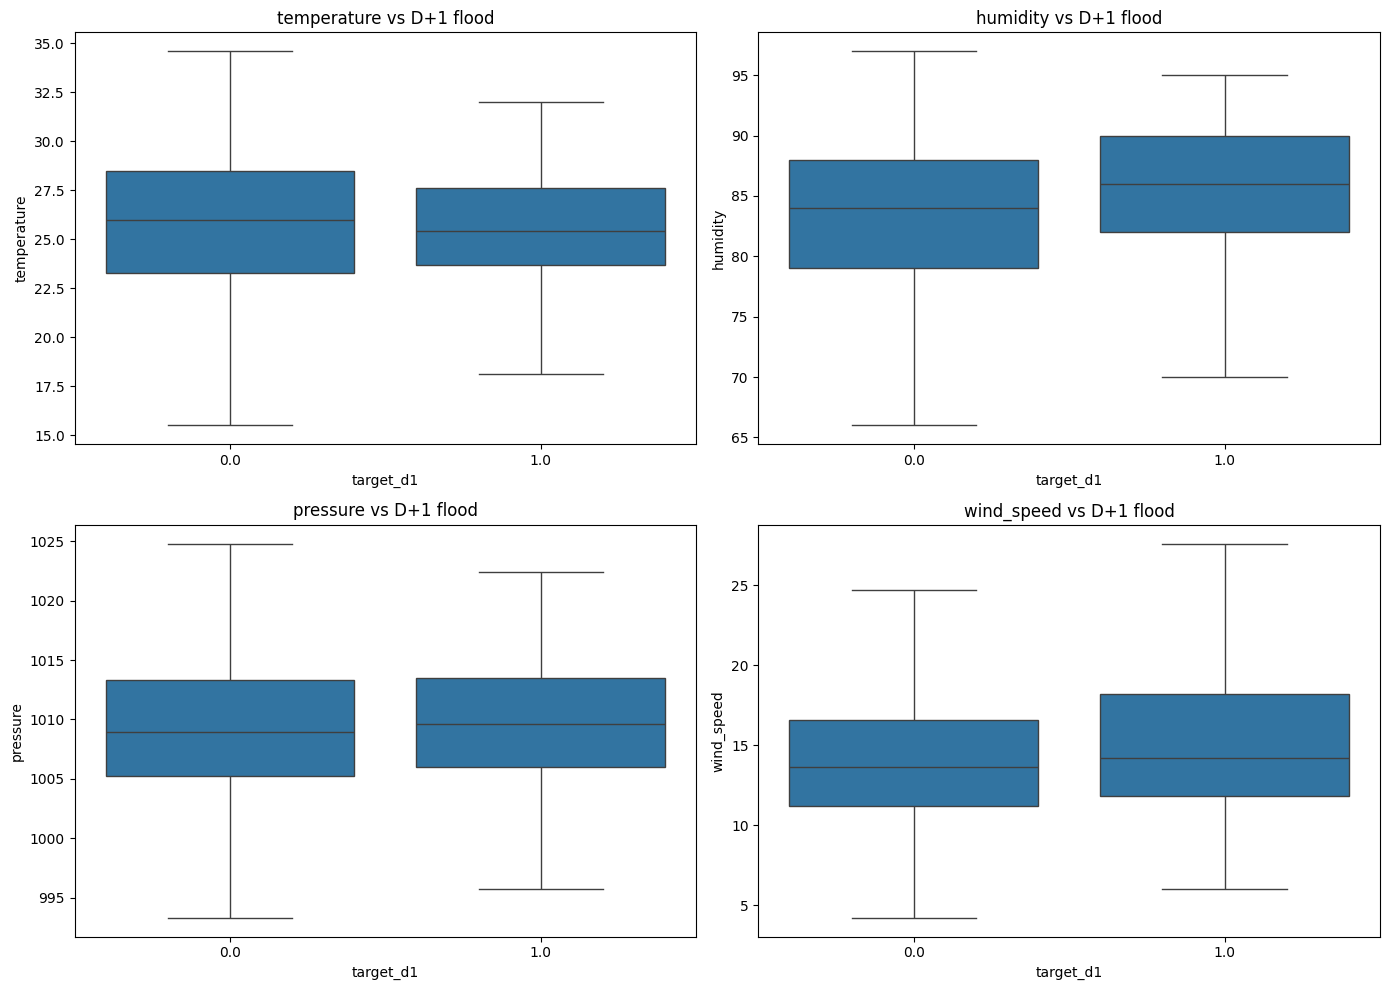

In [48]:
features = [
    "temperature",
    "humidity",
    "pressure",
    "wind_speed"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, feature in zip(axes.flatten(), features):
    sns.boxplot(
        data=df,
        x="target_d1",
        y=feature,
        showfliers=False,
        ax=ax
    )
    ax.set_title(f"{feature} vs D+1 flood")

plt.tight_layout()
plt.show()

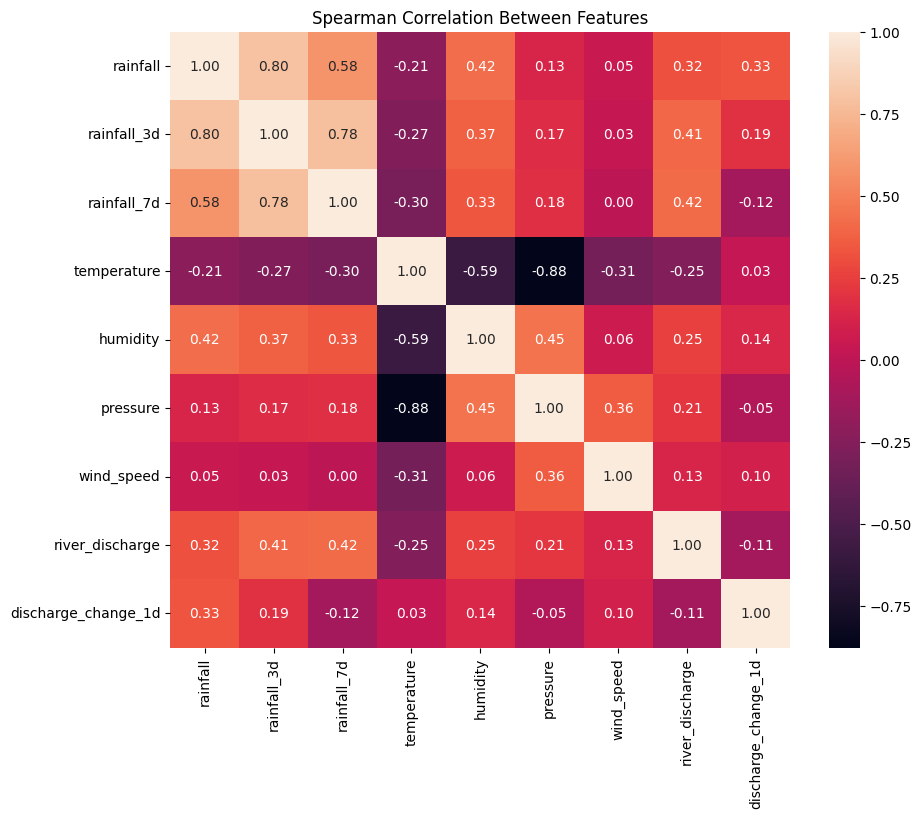

In [49]:
numeric_features = [
    "rainfall",
    "rainfall_3d",
    "rainfall_7d",
    "temperature",
    "humidity",
    "pressure",
    "wind_speed",
    "river_discharge",
    "discharge_change_1d"
]

corr = df[numeric_features].corr(method="spearman")

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Spearman Correlation Between Features")
plt.show()

In [53]:
df.to_csv("../data/train/train_data.csv",index = False)
print("Done")

Done
